<a href="https://colab.research.google.com/github/chanoosy/ML_TensorFlow_Flowers/blob/main/Flowers_TensorFlow.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Модули и GPU

In [1]:
import tensorflow as tf
import matplotlib.pyplot as plt
import PIL
import numpy as np
import pathlib

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential

if not tf.config.list_physical_devices('GPU'): print("GPU не найден")

##Установка датасета и вывод кол-ва изображений

In [2]:
import pathlib
dataset_url = "https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz"
dataset_dir = tf.keras.utils.get_file('flower_photos.tar', origin = dataset_url, extract = True)
dataset_dir = pathlib.Path(dataset_dir) / "flower_photos"

In [3]:
image_count = len(list(dataset_dir.glob("*/*.jpg")))
print(f"Кол-во изображений: {image_count}")

Кол-во изображений: 3670


##Создание и кэширование датасетов

In [4]:
dataset_dir = pathlib.Path("/root/.keras/datasets/flower_photos_extracted/flower_photos/")
batch_size = 32
img_width = 180
img_height = 180

train_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_dir,
    validation_split = 0.2,
    subset = "training",
    seed = 123,
    image_size = (img_height, img_width),
    batch_size = batch_size)

val_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_dir,
    validation_split = 0.2,
    subset = "validation",
    seed = 123,
    image_size = (img_height, img_width),
    batch_size = batch_size)

class_names = train_ds.class_names
print(f"class names: {class_names}")

#cache
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size = AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size = AUTOTUNE)

Found 3670 files belonging to 5 classes.
Using 2936 files for training.
Found 3670 files belonging to 5 classes.
Using 734 files for validation.
class names: ['daisy', 'dandelion', 'roses', 'sunflowers', 'tulips']


Создание модели, компиляция

In [5]:
# create model
num_classes = len(class_names)
model = Sequential([
  layers.Input(shape=(img_height, img_width, 3)),

	layers.Rescaling(1./255),

	layers.Conv2D(16, 3, padding='same', activation='relu'),
	layers.MaxPooling2D(),

	layers.Conv2D(32, 3, padding='same', activation='relu'),
	layers.MaxPooling2D(),

	layers.Conv2D(64, 3, padding='same', activation='relu'),
	layers.MaxPooling2D(),

	layers.Flatten(),
	layers.Dense(128, activation='relu'),
	layers.Dense(num_classes)
])

# compile the model
model.compile(
	optimizer='adam',
	loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
	metrics=['accuracy'])

# print model summary
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 180, 180, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 90, 90, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 90, 90, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 45, 45, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 45, 45, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 22, 22, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 30976)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,965,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,989,285 (15.22 MB)

 Trainable params: 3,989,285 (15.22 MB)

 Non-trainable params: 0 (0.00 B)

##Обучение и вывод графиков точности
###Из графиков становится заметно, что модель переобучилась

Epoch 1/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 17s 75ms/step - accuracy: 0.3158 - loss: 1.6181 - val_accuracy: 0.5409 - val_loss: 1.1034
Epoch 2/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.6077 - loss: 1.0116 - val_accuracy: 0.6512 - val_loss: 0.9591
Epoch 3/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.6981 - loss: 0.7872 - val_accuracy: 0.6226 - val_loss: 0.9402
Epoch 4/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.8023 - loss: 0.5496 - val_accuracy: 0.6553 - val_loss: 0.8972
Epoch 5/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.8894 - loss: 0.3226 - val_accuracy: 0.6485 - val_loss: 1.0306
Epoch 6/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.9470 - loss: 0.1788 - val_accuracy: 0.6063 - val_loss: 1.4205
Epoch 7/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.9708 - loss: 0.1061 - val_accuracy: 0.6417 - val_loss: 1.4016
Epoch 8/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.9795 - loss: 0.0689 - val_accuracy: 0.6499 - 

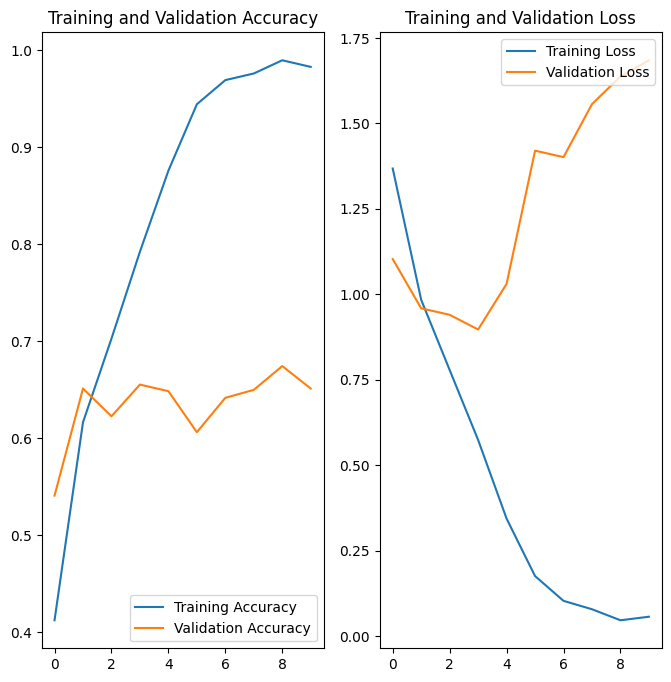

In [6]:
epochs = 10
history = model.fit(
	train_ds,
	validation_data=val_ds,
	epochs=epochs)

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(epochs)
plt.figure(figsize=(8, 8))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

##Решение проблемы переобучения с помощью аугментации и регуляризации

In [7]:
num_classes = len(class_names)

model = Sequential([
    #augmentation
    layers.Input(shape=(img_height, img_width, 3)),
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.15),
    layers.RandomContrast(0.2),

    layers.Rescaling(1./255),

    layers.Conv2D(16, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(32, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(64, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(128, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),

    #regularisation
    layers.Dropout(0.4),
    layers.Flatten(),

    layers.Dense(256, activation='relu'),
    layers.Dense(num_classes)
])

opt = tf.keras.optimizers.Adam(learning_rate=0.0005)

model.compile(
    optimizer=opt,
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)


##Повторное обучение с увеличением кол-ва эпох

Epoch 1/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 10s 44ms/step - accuracy: 0.3849 - loss: 1.3716 - val_accuracy: 0.5409 - val_loss: 1.1090 - learning_rate: 5.0000e-04
Epoch 2/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - accuracy: 0.6158 - loss: 0.9991 - val_accuracy: 0.6049 - val_loss: 1.0030 - learning_rate: 5.0000e-04
Epoch 3/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - accuracy: 0.6371 - loss: 0.9075 - val_accuracy: 0.6608 - val_loss: 0.8823 - learning_rate: 5.0000e-04
Epoch 4/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 5s 35ms/step - accuracy: 0.6788 - loss: 0.8483 - val_accuracy: 0.6975 - val_loss: 0.8117 - learning_rate: 5.0000e-04
Epoch 5/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - accuracy: 0.6903 - loss: 0.8004 - val_accuracy: 0.6689 - val_loss: 0.8447 - learning_rate: 5.0000e-04
Epoch 6/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 5s 33ms/step - accuracy: 0.6876 - loss: 0.8061 - val_accuracy: 0.7044 - val_loss: 0.7489 - learning_rate: 5.0000e-04
Epoch 7/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - accuracy: 0.7132

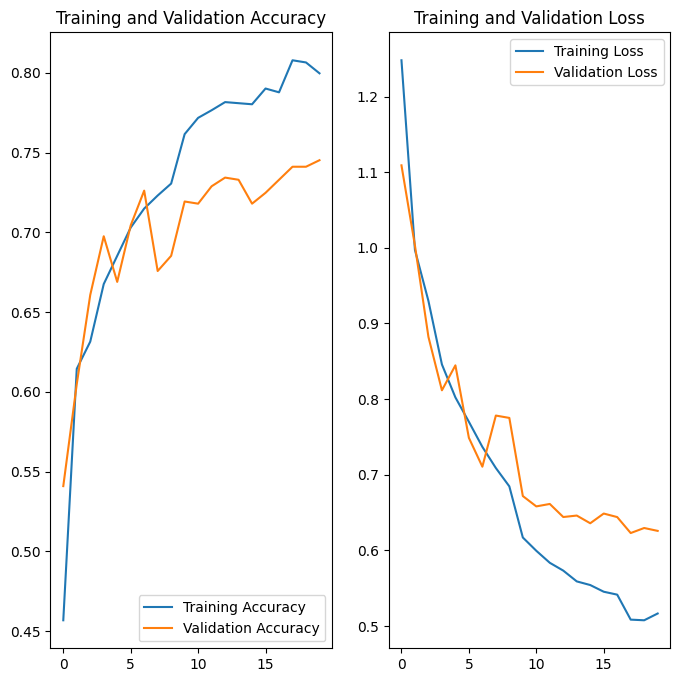

In [8]:
my_callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=4,
        restore_best_weights=True
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.2,
        patience=2,
        verbose=1
    )
]

epochs = 20
history = model.fit(
  train_ds,
  validation_data=val_ds,
  epochs=epochs,
  callbacks=my_callbacks
)

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(epochs)

plt.figure(figsize=(8, 8))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

##Инференс на новом изображении

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 215ms/step
На изображении скорее всего dandelion (74.52 % вероятность)


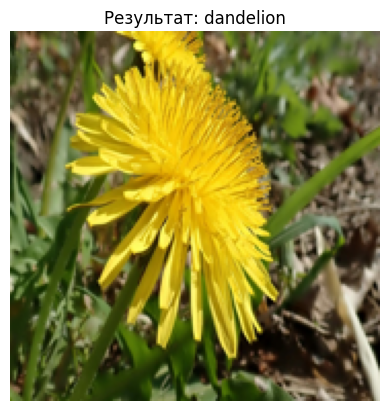

In [9]:
import requests
from PIL import Image
from io import BytesIO

flower_url = "https://avatars.mds.yandex.net/get-entity_search/10843572/1237481469/S600xU_2x"

response = requests.get(flower_url)
img = Image.open(BytesIO(response.content))
img = img.resize((img_width, img_height))

img_array = tf.keras.utils.img_to_array(img)
img_array = tf.expand_dims(img_array, 0)

predictions = model.predict(img_array)
score = tf.nn.softmax(predictions[0])

print("На изображении скорее всего {} ({:.2f} % вероятность)".format(
    class_names[np.argmax(score)], 100 * np.max(score)))

plt.imshow(img)
plt.title(f"Результат: {class_names[np.argmax(score)]}")
plt.axis('off')
plt.show()